In [180]:
import os
import pandas as pd
from datetime import datetime
import importlib
import numpy as np

np.set_printoptions(suppress=True)

In [181]:
# Relative imports
d = os.path.abspath(os.getcwd())
os.chdir("../..")
import hidden_state_model.processor
importlib.reload(hidden_state_model.processor)
Processor = hidden_state_model.processor.Processor
os.chdir(d)

### Read (and compact) dataframes

In [182]:
compact = False

In [183]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
data_dir = os.path.join(d, "..", "data")
for file in os.listdir(data_dir):
    fname = os.path.join(data_dir, file)
    if file.endswith(".parquet"):
        read.append(file)
        print(f"Reading {file}")
        df = pd.read_parquet(fname)
        dfs.append(df)
    if file.endswith(".csv"):
        read.append(file)
        df = pd.read_csv(fname, index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs)

if compact and len(dfs) > 10:
    print("Compacintg dfs")

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(os.path.join(data_dir, f"combined_{timestamp}.parquet"))

    # Move files already in trash to trash within trash
    trash = os.path.join(data_dir, "trash")
    trash_in_trash = os.path.join(trash, f"trash_{timestamp}")
    os.makedirs(trash_in_trash, exist_ok=True)
    for f in os.listdir(trash):
        if f.endswith(".parquet") or f.endswith(".csv"):
            os.rename(os.path.join(trash, f), os.path.join(trash_in_trash, f))
    
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    for f in read:
        os.rename(os.path.join(data_dir, f), os.path.join(trash, f))

dfs = []  # Clear memory
raw_df

Reading maxevplayer-2024-10-02_22-40-24.parquet
Reading combined_20241002224024.parquet


,prev_entry,public_cards,player_piles,current_player_i,bet_in_stage,bet_in_game,player_has_played,player_is_folded,first_better_i,big_blind,...,player_type,opponent_names,action,amount,p,relative_ev,rank,tiebreakers,hand_index,state_id
state_id,,,,,,,,,,,,,,,,,,,,,
cfd44dc6-587a-4dae-8c69-08aefde35f85,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,MaxEVPlayer,[Adrian],fold,0,0.5144,0.015432,0,"[11, 2, 0, 0, 0]",1071.0,NaN
b968f9ac-475f-4ce3-99bf-e10a167748a9,None,[],"[98, 96]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],fold,0,0.4310,0.012930,0,"[5, 1, 0, 0, 0]",279.0,NaN
40ca191b-a3a6-4d41-8899-9ab5ac4f8866,None,[],"[94, 98]",0,"[4, 4]","[4, 4]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],check,0,0.6276,0.025104,0,"[11, 10, 0, 0, 0]",465.0,NaN
f808b8aa-23f7-4bf4-b7c5-bbff1efe5168,40ca191b-a3a6-4d41-8899-9ab5ac4f8866,"[45, 18, 42]","[94, 94]",0,"[0, 4]","[4, 8]","[False, True]","[False, False]",1,4,...,HumanPlayer,[Max Mekker],fold,0,0.3821,0.022926,0,"[11, 10, 6, 5, 3]",465.0,NaN
dd0555b5-9484-4564-b36e-8c6e663b1bed,None,[],"[92, 102]",0,"[2, 4]","[2, 4]","[False, False]","[False, False]",0,4,...,HumanPlayer,[Max Mekker],call,2,0.5547,0.016641,0,"[11, 4, 0, 0, 0]",217.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4cd00d80-45c0-4637-ab95-acfe6acfd066,9206a8c0-49d4-4cfe-a014-f44e73eb0b2f,"[43, 36, 21, 23]","[81, 103]",1,"[0, 0]","[8, 8]","[False, False]","[False, False]",1,4,...,MaxEVPlayer,[Tord],raise,8,0.6955,0.055640,2,"[10, 4, 8, 0, 0]",755.0,NaN
7b16b4c0-5a1a-45ec-8fcb-402faccb257c,None,[],"[77, 115]",1,"[4, 4]","[4, 4]","[True, False]","[False, False]",0,4,...,MaxEVPlayer,[Tord],raise,4,0.5616,0.022464,0,"[11, 6, 0, 0, 0]",955.0,NaN
584fd5cc-cff2-4812-8b9a-d8d92fa4274a,7b16b4c0-5a1a-45ec-8fcb-402faccb257c,"[19, 42, 46]","[65, 111]",1,"[8, 0]","[16, 8]","[True, False]","[False, False]",0,4,...,MaxEVPlayer,[Tord],fold,0,0.6880,0.082560,1,"[6, 11, 7, 3, 0]",955.0,NaN


In [184]:
raw_df.dtypes

prev_entry            object
public_cards          object
player_piles          object
current_player_i       int64
bet_in_stage          object
bet_in_game           object
player_has_played     object
player_is_folded      object
first_better_i         int64
big_blind              int64
player_name           object
player_type           object
opponent_names        object
action                object
amount                 int64
p                    float64
relative_ev          float64
rank                   int64
tiebreakers           object
hand_index           float64
state_id             float64
dtype: object

In [185]:
# Check for conflicting rows
dupe_df = raw_df[raw_df.index.duplicated()]
assert len(dupe_df) == 0, dupe_df

## Process data

In [186]:
processor = Processor(raw_df)
df = processor.get_processed_df()
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,p,relative_ev,stage,player_name,human,opponent_name,n_players,is_all_in,hand_group,hand_suited
6127529072,0,0,0,0,0,0,0,0,0,0,...,0.5130,0.015390,preflop,Tord,True,,2,False,NaN,None
975a9f24-71f0-4b73-8b35-39e3a336d0f5,0,0,0,0,0,0,0,0,0,0,...,0.6265,0.018795,preflop,Tord,True,Max Mekker,2,False,2.0,False
eb5ca605-ee0d-4259-917b-88b14f74aabe,0,0,0,0,0,0,0,0,0,0,...,0.7006,0.042036,preflop,Adrian,False,Max Mekker,2,False,1.0,True
621a2362-7595-4e0a-b033-f66e1d658069,0,0,0,0,0,0,0,0,0,0,...,0.6027,0.018081,preflop,Adrian,False,Max Mekker,2,False,17.0,False
aa3a1306-d773-48a2-b6c1-ab3c5e261658,0,0,0,0,0,0,0,0,0,0,...,0.6056,0.018168,preflop,Max Mekker,False,Adrian,2,False,9.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6165583184,0,69,0,0,0,6,13,0,0,0,...,0.9015,0.811350,river,Arin,True,,2,True,NaN,None
6172605696,0,0,56,0,0,4,5,0,0,0,...,0.8551,0.641325,turn,Arin,True,,2,False,NaN,None
6162184512,0,22,21,0,0,6,5,10,0,0,...,0.8571,0.565686,river,Arin,True,,2,False,NaN,None
10963606496,0,0,72,0,0,4,5,0,0,0,...,0.8551,0.752488,turn,Arin,True,,2,False,NaN,None


In [187]:
# Drop any rows where hand_group is NaN
df = df.dropna(subset=["hand_group"])
df

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,p,relative_ev,stage,player_name,human,opponent_name,n_players,is_all_in,hand_group,hand_suited
975a9f24-71f0-4b73-8b35-39e3a336d0f5,0,0,0,0,0,0,0,0,0,0,...,0.6265,0.018795,preflop,Tord,True,Max Mekker,2,False,2.0,False
eb5ca605-ee0d-4259-917b-88b14f74aabe,0,0,0,0,0,0,0,0,0,0,...,0.7006,0.042036,preflop,Adrian,False,Max Mekker,2,False,1.0,True
621a2362-7595-4e0a-b033-f66e1d658069,0,0,0,0,0,0,0,0,0,0,...,0.6027,0.018081,preflop,Adrian,False,Max Mekker,2,False,17.0,False
aa3a1306-d773-48a2-b6c1-ab3c5e261658,0,0,0,0,0,0,0,0,0,0,...,0.6056,0.018168,preflop,Max Mekker,False,Adrian,2,False,9.0,True
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,0,0,0,0,0,0,0,0,0,0,...,0.4649,0.027894,preflop,Max Mekker,False,Adrian,2,False,78.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83a2a524-5713-44d6-b490-e2ece47b78b8,0,0,34,0,0,2,4,17,0,0,...,0.8092,0.477428,river,Max Mekker,False,Adrian,2,False,25.0,False
3b02ed4c-770e-40aa-9cfc-bf58e9e23a21,14,49,0,0,0,13,22,0,0,0,...,0.6424,0.642400,turn,Max Mekker,False,Adrian,2,True,65.0,False
3be60c17-6c95-4d6a-acce-93ac54b75308,0,0,0,0,0,6,7,13,0,0,...,0.9355,0.416298,river,Tord,True,Max Mekker,2,False,56.0,False
ede7472b-9d5a-451c-8893-511a2085bfcd,6,0,0,0,0,4,7,17,0,0,...,0.8207,0.471902,river,Max Mekker,False,Adrian,2,False,1.0,True


## Examine data

In [188]:
dict(df.dtypes)

{'raise_preflop': dtype('int64'),
 'raise_flop': dtype('int64'),
 'raise_turn': dtype('int64'),
 'raise_river': dtype('int64'),
 'raise_showdown': dtype('int64'),
 'call_preflop': dtype('int64'),
 'call_flop': dtype('int64'),
 'call_turn': dtype('int64'),
 'call_river': dtype('int64'),
 'call_showdown': dtype('int64'),
 'check_preflop': dtype('int64'),
 'check_flop': dtype('int64'),
 'check_turn': dtype('int64'),
 'check_river': dtype('int64'),
 'check_showdown': dtype('int64'),
 'opponent_raise_preflop': dtype('int64'),
 'opponent_raise_flop': dtype('int64'),
 'opponent_raise_turn': dtype('int64'),
 'opponent_raise_river': dtype('int64'),
 'opponent_raise_showdown': dtype('int64'),
 'opponent_call_preflop': dtype('int64'),
 'opponent_call_flop': dtype('int64'),
 'opponent_call_turn': dtype('int64'),
 'opponent_call_river': dtype('int64'),
 'opponent_call_showdown': dtype('int64'),
 'opponent_check_preflop': dtype('int64'),
 'opponent_check_flop': dtype('int64'),
 'opponent_check_turn'

<Axes: title={'center': 'Occurrences of each hand group'}, xlabel='hand_group'>

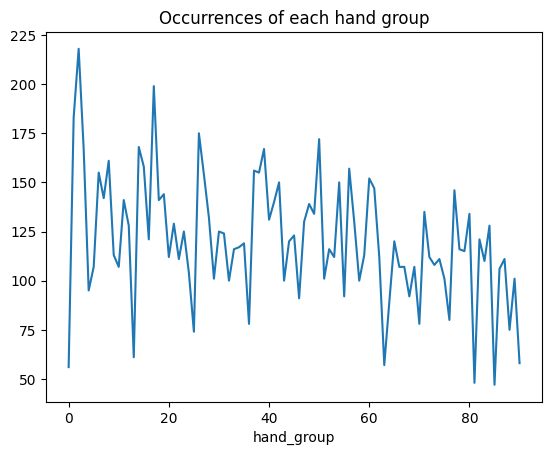

In [189]:
df.groupby("hand_group").size().plot(title="Occurrences of each hand group")

In [190]:
df.groupby("human").size()

human
False    7820
True     3151
dtype: int64

In [191]:
df.groupby("player_name").size().sort_values(ascending=False)

player_name
Adrian        3947
Max Mekker    3873
Tord          1339
t              364
Finn           324
Jacob          296
Arin           292
Henning        291
Kristian        95
Syver           84
Jakob           48
Alun            18
dtype: int64

<Axes: title={'center': 'Occurrences of each card on the table'}>

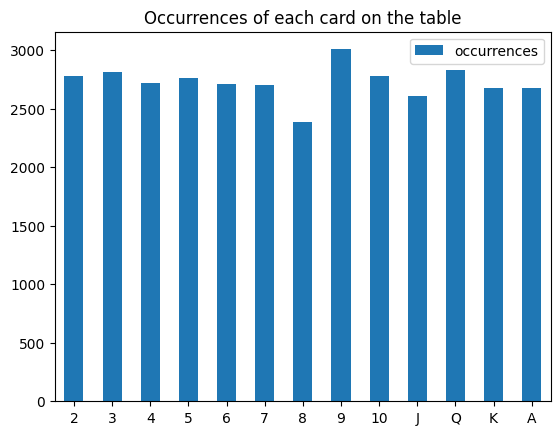

In [192]:
from cpp_poker.cpp_poker import Card

card_occurences_on_table = []
for value in Card.VALUES:
    card_occurences_on_table.append(df[f"n_{value}_on_table"].sum())
pd.DataFrame(dict(zip(Card.VALUES, card_occurences_on_table)), index=["occurrences"]).T.plot(
    title="Occurrences of each card on the table", kind="bar", rot=0
)

## Training

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [201]:
X = df.drop(
    [
        # These must be dropped to avoid data leakage
        "excess_rank",
        "game_id",
        "p",
        "relative_ev",
        "hand_group",
        "hand_suited",

        # Drop these columns to avoid overfitting
        "player_name",
        "opponent_name",
    ],
    axis=1,
)
Y = df[["hand_group", "hand_suited"]]
groups = df["game_id"]  # Group by 'game_id' to ensure no data leakage

In [202]:
X

,raise_preflop,raise_flop,raise_turn,raise_river,raise_showdown,call_preflop,call_flop,call_turn,call_river,call_showdown,...,n_♥_on_table,n_♦_on_table,n_♣_on_table,n_♠_on_table,action,amount,stage,human,n_players,is_all_in
975a9f24-71f0-4b73-8b35-39e3a336d0f5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,2,preflop,True,2,False
eb5ca605-ee0d-4259-917b-88b14f74aabe,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,4,preflop,False,2,False
621a2362-7595-4e0a-b033-f66e1d658069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,raise,6,preflop,False,2,False
aa3a1306-d773-48a2-b6c1-ab3c5e261658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,raise,6,preflop,False,2,False
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,call,4,preflop,False,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83a2a524-5713-44d6-b490-e2ece47b78b8,0,0,34,0,0,2,4,17,0,0,...,10,0,12,1,raise,34,river,False,2,False
3b02ed4c-770e-40aa-9cfc-bf58e9e23a21,14,49,0,0,0,13,22,0,0,0,...,4,0,5,4,check,0,turn,False,2,True
3be60c17-6c95-4d6a-acce-93ac54b75308,0,0,0,0,0,6,7,13,0,0,...,6,6,6,6,call,33,river,True,2,False
ede7472b-9d5a-451c-8893-511a2085bfcd,6,0,0,0,0,4,7,17,0,0,...,2,0,16,6,call,43,river,False,2,False


In [203]:
Y

,hand_group,hand_suited
975a9f24-71f0-4b73-8b35-39e3a336d0f5,2.0,False
eb5ca605-ee0d-4259-917b-88b14f74aabe,1.0,True
621a2362-7595-4e0a-b033-f66e1d658069,17.0,False
aa3a1306-d773-48a2-b6c1-ab3c5e261658,9.0,True
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,78.0,True
...,...,...
83a2a524-5713-44d6-b490-e2ece47b78b8,25.0,False
3b02ed4c-770e-40aa-9cfc-bf58e9e23a21,65.0,False
3be60c17-6c95-4d6a-acce-93ac54b75308,56.0,False
ede7472b-9d5a-451c-8893-511a2085bfcd,1.0,True


In [204]:
# Identify categorical columns (excluding 'game_id')
categorical_cols = [
    "action",
    "stage",
    # "player_name",
    # "opponent_name",
]

# Preprocessing pipeline: OneHotEncoding for categorical and scaling for numerical
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(drop="first"), categorical_cols)],
    remainder="passthrough",
)

# Create the full pipeline with logistic regression
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "classifier",
            LogisticRegression(
                multi_class="multinomial", solver="lbfgs", max_iter=10_000
            ),
        ),
    ]
)

In [205]:
# Grouped train-test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (8810, 53)
Test shape: (2161, 53)


In [206]:
# Only predict hand_group index (not suited) for now
y_train_cls = Y_train["hand_group"]
y_test_cls = Y_test["hand_group"]

In [207]:
# Train the model
model.fit(X_train, y_train_cls)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage'])])),
                ('classifier',
                 LogisticRegression(max_iter=10000,
                                    multi_class='multinomial'))])

In [208]:
# Evaluate the model
accuracy = model.score(X_test, y_test_cls)
print(f"Accuracy: {accuracy}")

Accuracy: 0.011105969458583989


In [209]:
probabilities = model.predict_proba(X_test)
prob_df = pd.DataFrame(probabilities, columns=model.classes_, index=X_test.index)
prob_df["true"] = y_test_cls.values
prob_df["pred"] = model.predict(X_test)
prob_df["correct"] = prob_df["true"] == prob_df["pred"]
prob_df["goodness"] = prob_df.apply(lambda x: x.get(x["true"]) or 0, axis=1)
print("Accuracy", prob_df["correct"].mean())
print("Mean goodness: ", prob_df["goodness"].mean())
prob_df

Accuracy 0.011105969458583989
Mean goodness:  0.012214296024933347


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,85.0,86.0,87.0,88.0,89.0,90.0,true,pred,correct,goodness
eb5ca605-ee0d-4259-917b-88b14f74aabe,2.663725e-03,1.345996e-02,1.159307e-02,1.537016e-02,1.228974e-02,8.783167e-03,0.020036,2.237011e-02,1.374968e-02,8.901345e-03,...,4.690018e-03,8.095658e-03,8.894217e-03,4.084212e-03,9.348032e-03,6.511640e-03,1.0,7.0,False,1.345996e-02
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,2.663725e-03,1.345996e-02,1.159307e-02,1.537016e-02,1.228974e-02,8.783167e-03,0.020036,2.237011e-02,1.374968e-02,8.901345e-03,...,4.690018e-03,8.095658e-03,8.894217e-03,4.084212e-03,9.348032e-03,6.511640e-03,78.0,7.0,False,1.739987e-02
0ef1b785-4321-4d5a-85b1-42ea82eb156e,9.856472e-03,1.753034e-02,4.169045e-02,2.015587e-02,2.720816e-03,2.049702e-02,0.009193,4.692679e-03,1.350248e-02,1.041652e-02,...,7.053241e-03,8.724081e-03,1.187245e-02,4.629226e-03,5.601845e-03,1.585237e-03,17.0,2.0,False,1.782524e-02
6e2d8a1b-8313-4b5d-b603-fd0d154a10d6,2.585024e-03,1.326694e-02,1.126695e-02,1.574933e-02,1.212383e-02,8.498106e-03,0.020848,2.308548e-02,1.348453e-02,9.753020e-03,...,4.356610e-03,8.851507e-03,8.896554e-03,4.574749e-03,9.151893e-03,6.894848e-03,20.0,7.0,False,7.097940e-03
0cae6a7e-2c4e-4a20-b151-aca74584a2bd,9.162928e-03,2.086499e-02,1.983834e-02,1.411808e-02,9.979897e-03,1.381546e-02,0.014114,1.121193e-02,1.906387e-02,1.157923e-02,...,6.948128e-03,8.648356e-03,7.765346e-03,6.734829e-03,6.301989e-03,4.929057e-03,27.0,1.0,False,1.236057e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff456bfa-5262-4cf9-a1d1-f0d144e2a1c5,1.703166e-17,6.342023e-21,3.454731e-26,3.516678e-20,5.708641e-07,4.527508e-30,0.007518,1.481781e-22,1.596447e-18,2.462413e-19,...,1.031844e-21,1.044736e-24,3.467019e-22,3.095815e-26,6.530696e-16,8.654730e-11,27.0,37.0,False,3.234216e-20
b57b4d49-ebd2-4ef5-9662-d22de558dd26,6.758545e-07,3.094037e-04,3.236672e-03,1.980394e-02,5.601041e-07,4.003999e-06,0.005142,5.219161e-03,1.422351e-02,5.049191e-03,...,4.590222e-07,2.194916e-07,2.342729e-03,2.568206e-02,1.259980e-05,9.383600e-03,32.0,23.0,False,3.932526e-06
c024522a-bc8d-458a-b381-581e9e22b82f,2.073573e-05,1.222838e-02,7.297953e-03,4.313504e-01,3.168435e-04,2.831726e-06,0.014326,7.428123e-03,1.335184e-05,3.598187e-03,...,2.521907e-12,1.703161e-10,1.073985e-03,5.963599e-02,2.992546e-11,2.699405e-10,38.0,3.0,False,2.325252e-04
1abeb2aa-251a-45c0-bba9-67dbdc8a374a,2.795576e-04,9.595554e-04,2.768884e-02,1.474669e-02,1.536395e-07,3.915103e-08,0.031689,1.169510e-05,2.051077e-03,4.760400e-03,...,6.415329e-10,7.492139e-09,2.485360e-03,4.002890e-04,4.147076e-10,3.056506e-09,47.0,50.0,False,2.038560e-04


In [210]:
# Look at incorrect predictions
print(prob_df[prob_df["correct"] == False].shape[0], "incorrect predictions:")
prob_df[prob_df["correct"] == False]

2137 incorrect predictions:


,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,85.0,86.0,87.0,88.0,89.0,90.0,true,pred,correct,goodness
eb5ca605-ee0d-4259-917b-88b14f74aabe,2.663725e-03,1.345996e-02,1.159307e-02,1.537016e-02,1.228974e-02,8.783167e-03,0.020036,2.237011e-02,1.374968e-02,8.901345e-03,...,4.690018e-03,8.095658e-03,8.894217e-03,4.084212e-03,9.348032e-03,6.511640e-03,1.0,7.0,False,1.345996e-02
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,2.663725e-03,1.345996e-02,1.159307e-02,1.537016e-02,1.228974e-02,8.783167e-03,0.020036,2.237011e-02,1.374968e-02,8.901345e-03,...,4.690018e-03,8.095658e-03,8.894217e-03,4.084212e-03,9.348032e-03,6.511640e-03,78.0,7.0,False,1.739987e-02
0ef1b785-4321-4d5a-85b1-42ea82eb156e,9.856472e-03,1.753034e-02,4.169045e-02,2.015587e-02,2.720816e-03,2.049702e-02,0.009193,4.692679e-03,1.350248e-02,1.041652e-02,...,7.053241e-03,8.724081e-03,1.187245e-02,4.629226e-03,5.601845e-03,1.585237e-03,17.0,2.0,False,1.782524e-02
6e2d8a1b-8313-4b5d-b603-fd0d154a10d6,2.585024e-03,1.326694e-02,1.126695e-02,1.574933e-02,1.212383e-02,8.498106e-03,0.020848,2.308548e-02,1.348453e-02,9.753020e-03,...,4.356610e-03,8.851507e-03,8.896554e-03,4.574749e-03,9.151893e-03,6.894848e-03,20.0,7.0,False,7.097940e-03
0cae6a7e-2c4e-4a20-b151-aca74584a2bd,9.162928e-03,2.086499e-02,1.983834e-02,1.411808e-02,9.979897e-03,1.381546e-02,0.014114,1.121193e-02,1.906387e-02,1.157923e-02,...,6.948128e-03,8.648356e-03,7.765346e-03,6.734829e-03,6.301989e-03,4.929057e-03,27.0,1.0,False,1.236057e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff456bfa-5262-4cf9-a1d1-f0d144e2a1c5,1.703166e-17,6.342023e-21,3.454731e-26,3.516678e-20,5.708641e-07,4.527508e-30,0.007518,1.481781e-22,1.596447e-18,2.462413e-19,...,1.031844e-21,1.044736e-24,3.467019e-22,3.095815e-26,6.530696e-16,8.654730e-11,27.0,37.0,False,3.234216e-20
b57b4d49-ebd2-4ef5-9662-d22de558dd26,6.758545e-07,3.094037e-04,3.236672e-03,1.980394e-02,5.601041e-07,4.003999e-06,0.005142,5.219161e-03,1.422351e-02,5.049191e-03,...,4.590222e-07,2.194916e-07,2.342729e-03,2.568206e-02,1.259980e-05,9.383600e-03,32.0,23.0,False,3.932526e-06
c024522a-bc8d-458a-b381-581e9e22b82f,2.073573e-05,1.222838e-02,7.297953e-03,4.313504e-01,3.168435e-04,2.831726e-06,0.014326,7.428123e-03,1.335184e-05,3.598187e-03,...,2.521907e-12,1.703161e-10,1.073985e-03,5.963599e-02,2.992546e-11,2.699405e-10,38.0,3.0,False,2.325252e-04
1abeb2aa-251a-45c0-bba9-67dbdc8a374a,2.795576e-04,9.595554e-04,2.768884e-02,1.474669e-02,1.536395e-07,3.915103e-08,0.031689,1.169510e-05,2.051077e-03,4.760400e-03,...,6.415329e-10,7.492139e-09,2.485360e-03,4.002890e-04,4.147076e-10,3.056506e-09,47.0,50.0,False,2.038560e-04


### Compare to XGBoost

In [211]:
from xgboost import XGBClassifier

# Create the full pipeline with XGBoost
model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "classifier",
            XGBClassifier(),
        ),
    ]
)

In [212]:
cross_validate = False

In [213]:
if cross_validate:
    # Cross validate to find good hyperparameters
    from sklearn.model_selection import GridSearchCV

    # Define the parameter grid
    param_grid = {
        'classifier__n_estimators': [100, 500],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.6, 0.8, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0],
    }

    # Grid search over the XGBRegressor parameters
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model
    grid_search.fit(X_train, y_train_cls)

    # Best parameters and score
    print(grid_search.best_params_)
    print(grid_search.best_score_)
    
    # Use the best model
    model = grid_search.best_estimator_

In [214]:
# Train the model
model.fit(X_train, y_train_cls)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['action', 'stage'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eva...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [215]:
# Evaluate the model
accuracy = model.score(X_test, y_test_cls)
print(f"Accuracy: {accuracy}")

Accuracy: 0.022211938917167977


In [216]:
probabilities = model.predict_proba(X_test)
prob_df = pd.DataFrame(probabilities, columns=model.classes_, index=X_test.index)
prob_df["true"] = y_test_cls.values
prob_df["pred"] = model.predict(X_test)
prob_df["correct"] = prob_df["true"] == prob_df["pred"]
prob_df["goodness"] = prob_df.apply(lambda x: x.get(x["true"]) or 0, axis=1)
print("Accuracy", prob_df["correct"].mean())
print("Mean goodness: ", prob_df["goodness"].mean())
prob_df

Accuracy 0.022211938917167977
Mean goodness:  0.015559313695395286


,0,1,2,3,4,5,6,7,8,9,...,85,86,87,88,89,90,true,pred,correct,goodness
eb5ca605-ee0d-4259-917b-88b14f74aabe,0.009300,0.016715,0.011812,0.015012,0.008097,0.004623,0.019977,0.026541,0.013291,0.008748,...,0.009803,0.009603,0.007468,0.002817,0.008338,0.001079,1.0,7,False,0.016715
ea0ec78f-683c-4d71-8db5-b3ffa61f6913,0.009300,0.016715,0.011812,0.015012,0.008097,0.004623,0.019977,0.026541,0.013291,0.008748,...,0.009803,0.009603,0.007468,0.002817,0.008338,0.001079,78.0,7,False,0.011717
0ef1b785-4321-4d5a-85b1-42ea82eb156e,0.006954,0.007880,0.019011,0.005683,0.002302,0.001878,0.001707,0.057163,0.040604,0.002084,...,0.000997,0.005174,0.001714,0.001145,0.001455,0.049823,17.0,17,True,0.063408
6e2d8a1b-8313-4b5d-b603-fd0d154a10d6,0.000390,0.005363,0.012015,0.014324,0.007122,0.003278,0.015168,0.023140,0.016618,0.007169,...,0.001148,0.009163,0.007196,0.002045,0.009947,0.017129,20.0,30,False,0.008627
0cae6a7e-2c4e-4a20-b151-aca74584a2bd,0.011382,0.028366,0.013229,0.019967,0.006856,0.019461,0.005462,0.013688,0.035627,0.010042,...,0.003345,0.001223,0.010484,0.000436,0.003244,0.004157,27.0,38,False,0.014310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ff456bfa-5262-4cf9-a1d1-f0d144e2a1c5,0.000571,0.005606,0.000988,0.004761,0.003093,0.000285,0.000480,0.011200,0.007095,0.000415,...,0.000813,0.004057,0.006369,0.000615,0.003752,0.000368,27.0,17,False,0.006279
b57b4d49-ebd2-4ef5-9662-d22de558dd26,0.000009,0.000099,0.001733,0.001239,0.000034,0.000021,0.000767,0.001397,0.017930,0.000822,...,0.000041,0.000212,0.000678,0.000576,0.000057,0.000135,32.0,27,False,0.000014
c024522a-bc8d-458a-b381-581e9e22b82f,0.002495,0.008014,0.015077,0.047123,0.001317,0.000103,0.005778,0.028409,0.002500,0.026655,...,0.000501,0.000479,0.001416,0.010663,0.000207,0.000251,38.0,19,False,0.000735
1abeb2aa-251a-45c0-bba9-67dbdc8a374a,0.000161,0.000661,0.002007,0.007069,0.000044,0.000345,0.160409,0.004276,0.000555,0.000737,...,0.000036,0.000077,0.000100,0.000760,0.000012,0.000366,47.0,34,False,0.000323


<Axes: title={'center': 'Feature importances'}>

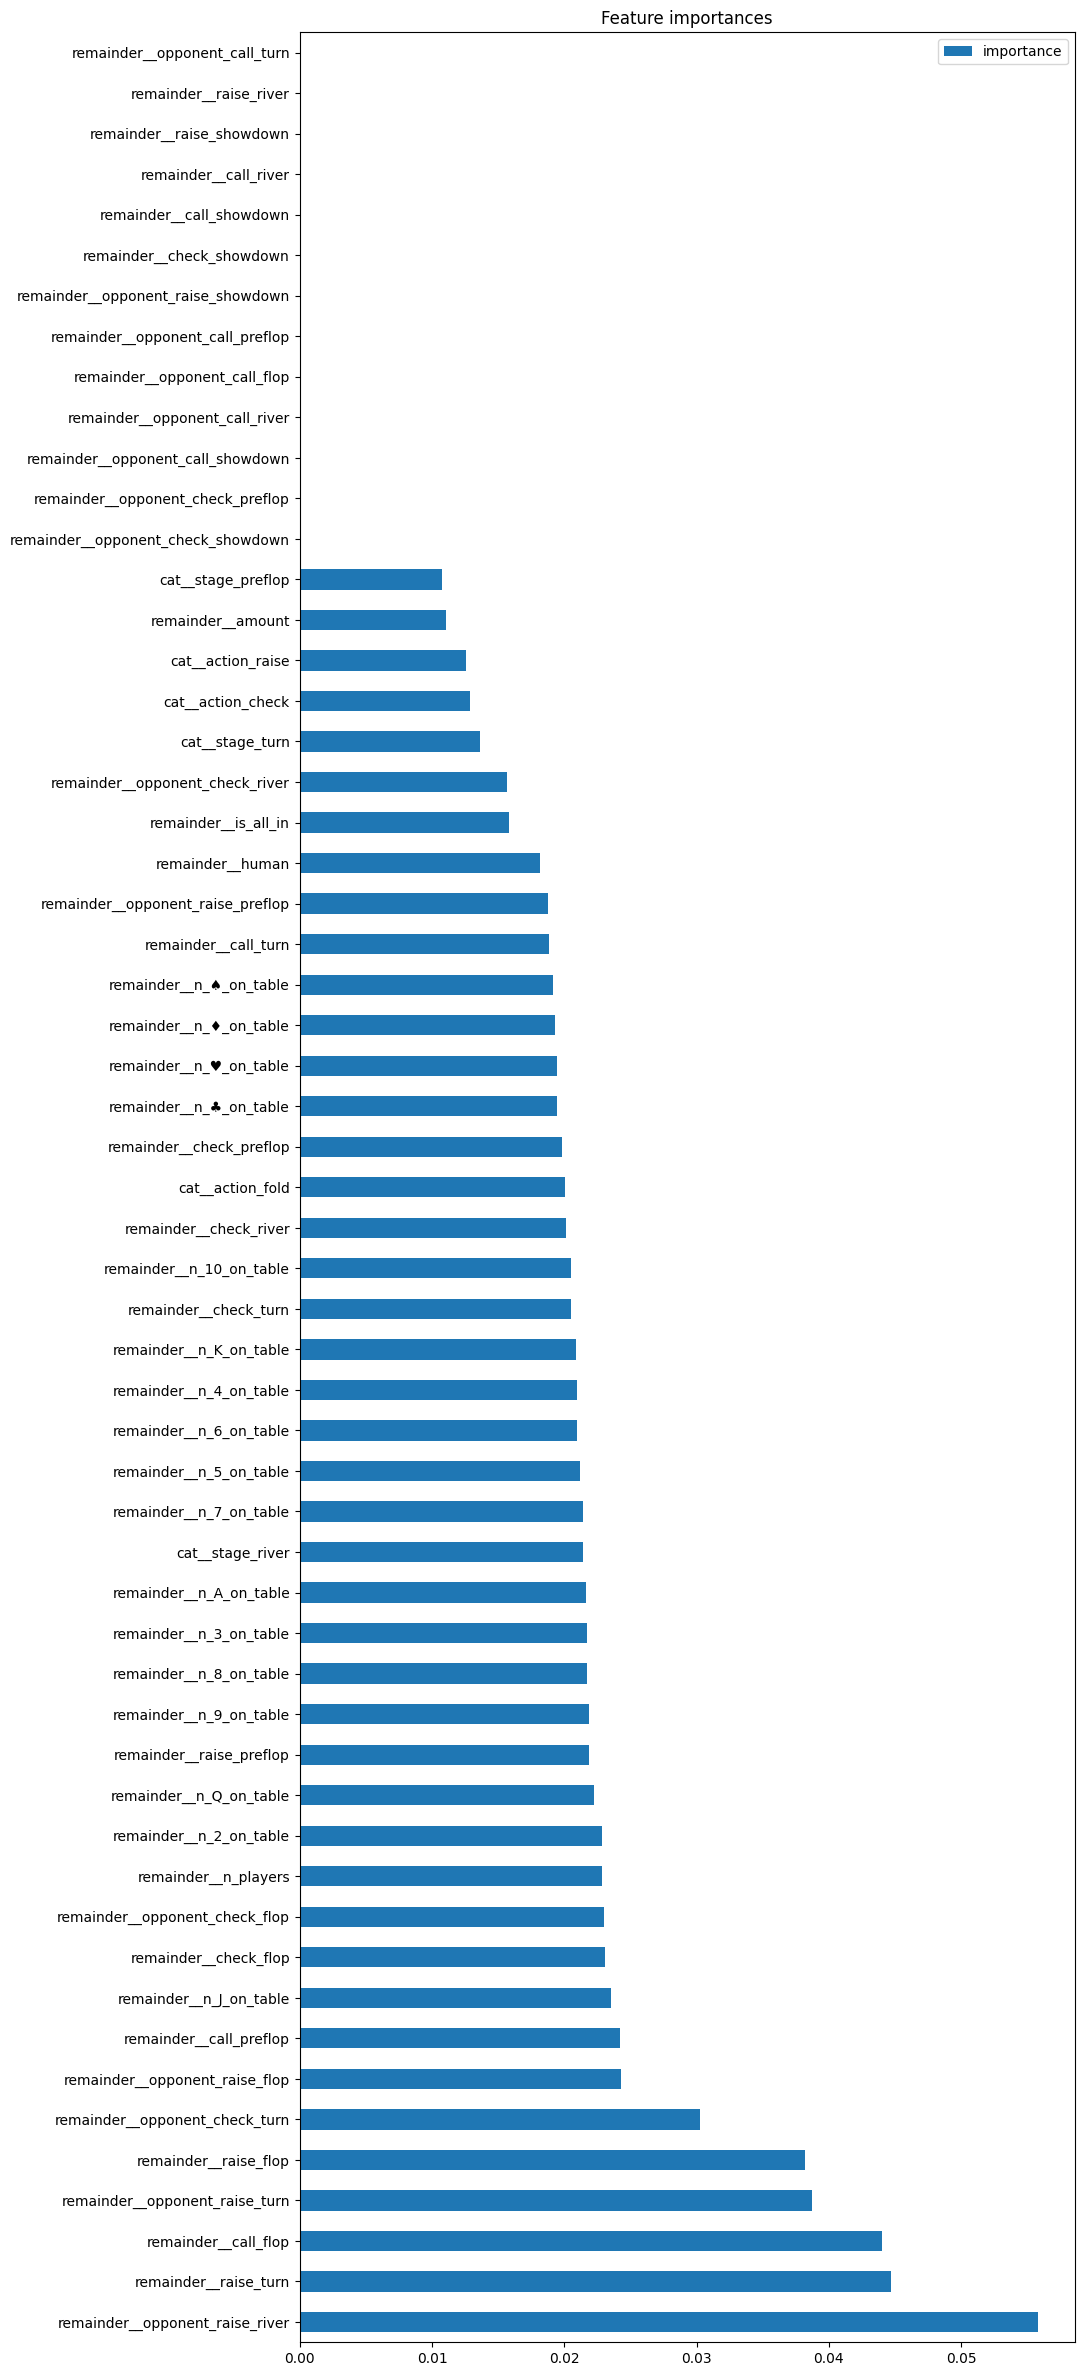

In [217]:
# Examine feature importances
importances = model.named_steps["classifier"].feature_importances_
feature_names = model.named_steps["preprocess"].get_feature_names_out()
importances_df = pd.DataFrame(importances, index=feature_names, columns=["importance"])
importances_df.sort_values("importance", ascending=False).plot(kind="barh", title="Feature importances", figsize=(10, 30))

## Compare to a neural network

In [218]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [219]:
# Convert target variable to categorical
y_train_cat = to_categorical(y_train_cls)
y_test_cat = to_categorical(y_test_cls)

In [220]:
# Convert categorical input features (`categorical_cols`) to one-hot encoding
X_train_cat = preprocessor.fit_transform(X_train)
X_test_cat = preprocessor.transform(X_test)

In [221]:
# Scale input features
scaler = StandardScaler()

# Step 2: Fit the scaler on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_cat)
X_test_scaled = scaler.transform(X_test_cat)

In [222]:
# Convert to tensors
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_cat_tensor = tf.convert_to_tensor(y_train_cat, dtype=tf.float32)
y_train_suited_tensor = tf.convert_to_tensor(Y_train["hand_suited"], dtype=tf.float32)
y_test_cat_tensor = tf.convert_to_tensor(y_test_cat, dtype=tf.float32)
y_test_suited_tensor = tf.convert_to_tensor(Y_test["hand_suited"], dtype=tf.float32)

# Expand dims to get (num_samples, 1) shape
y_train_suited_tensor = tf.expand_dims(y_train_suited_tensor, axis=-1)
y_test_suited_tensor = tf.expand_dims(y_test_suited_tensor, axis=-1)

In [223]:
# Define the input layer
input_layer = Input(shape=(X_train_tensor.shape[1],))

# Shared layers
x = Dense(512)(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# First output for hand groups
hand_group_output = Dense(91, activation="softmax", name="hand_group")(x)

# Second output for suited status
is_suited_output = Dense(1, activation="sigmoid", name="is_suited")(x)

# Define the model with two outputs
model_nn = Model(inputs=input_layer, outputs=[hand_group_output, is_suited_output])

# Compile the model with appropriate loss functions
model_nn.compile(
    optimizer=Adam(learning_rate=.01),
    loss={"hand_group": "categorical_crossentropy", "is_suited": "binary_crossentropy"},
    metrics=["accuracy"],
)

In [224]:
# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

In [225]:
# Train the model
model_nn.fit(
    X_train_tensor,
    {
        "hand_group": y_train_cat_tensor,
        "is_suited": y_train_suited_tensor,
    },
    epochs=30,
    batch_size=32,
    validation_data=(
        X_test_tensor,
        {"hand_group": y_test_cat_tensor, "is_suited": y_test_suited_tensor},
    ),
    # callbacks=[early_stopping],
)

Epoch 1/30


2024-10-03 20:13:58.831598: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


276/276 [==============================] - ETA: 0s - loss: 5.6596 - hand_group_loss: 5.0464 - is_suited_loss: 0.6132 - hand_group_accuracy: 0.0154 - is_suited_accuracy: 0.7372

2024-10-03 20:14:12.580409: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


276/276 [==============================] - 16s 50ms/step - loss: 5.6596 - hand_group_loss: 5.0464 - is_suited_loss: 0.6132 - hand_group_accuracy: 0.0154 - is_suited_accuracy: 0.7372 - val_loss: 5.1585 - val_hand_group_loss: 4.6223 - val_is_suited_loss: 0.5362 - val_hand_group_accuracy: 0.0148 - val_is_suited_accuracy: 0.7765
Epoch 2/30
276/276 [==============================] - 9s 34ms/step - loss: 5.0567 - hand_group_loss: 4.4904 - is_suited_loss: 0.5663 - hand_group_accuracy: 0.0174 - is_suited_accuracy: 0.7471 - val_loss: 5.0414 - val_hand_group_loss: 4.5077 - val_is_suited_loss: 0.5337 - val_hand_group_accuracy: 0.0217 - val_is_suited_accuracy: 0.7765
Epoch 3/30
276/276 [==============================] - 9s 32ms/step - loss: 5.0301 - hand_group_loss: 4.4647 - is_suited_loss: 0.5655 - hand_group_accuracy: 0.0196 - is_suited_accuracy: 0.7469 - val_loss: 5.0395 - val_hand_group_loss: 4.5074 - val_is_suited_loss: 0.5321 - val_hand_group_accuracy: 0.0199 - val_is_suited_accuracy: 0.7765

In [226]:
# Evaluate the model
evaluation = model_nn.evaluate(
    X_test_tensor,
    {
        "hand_group": y_test_cat_tensor,
        "is_suited": y_test_suited_tensor,
    },
)
print(evaluation)
total_loss, hand_group_loss, suited_loss, hand_group_accuracy, suited_accuracy = evaluation
print(f"Total loss: {total_loss}")
print(f"Hand group loss: {hand_group_loss}")
print(f"Suited loss: {suited_loss}")
print(f"Hand group accuracy: {hand_group_accuracy}")
print(f"Suited accuracy: {suited_accuracy}")

68/68 [==============================] - 1s 17ms/step - loss: 5.0231 - hand_group_loss: 4.4857 - is_suited_loss: 0.5374 - hand_group_accuracy: 0.0190 - is_suited_accuracy: 0.7765
[5.023078441619873, 4.485658645629883, 0.5374187231063843, 0.018972696736454964, 0.7764923572540283]
Total loss: 5.023078441619873
Hand group loss: 4.485658645629883
Suited loss: 0.5374187231063843
Hand group accuracy: 0.018972696736454964
Suited accuracy: 0.7764923572540283


In [227]:
from cpp_poker.cpp_poker import HandGroup

class_preds, suitedness_preds = model_nn.predict(X_test_tensor)
class_labels = [
    tuple((Card.VALUES[rank] for rank in group))
    for group in HandGroup.UNSUITED_COMBINATIONS
]

2024-10-03 20:19:13.739720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


68/68 [==============================] - 1s 5ms/step


(array([484.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,  21.,   0.,   0., 907.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,  10.,   0.,   0.,   0., 642.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,  97.]),
 array([ 1.        ,  1.91208791,  2.82417582,  3.73626374,  4.64835165,
         5.56043956,  6.47252747,  7.38461538,  8.2967033 ,  9.20879121,
        10.12087912, 11.03296703, 11.94505495, 12.85714286, 13.76923077,
        14.68131868, 15.59340659, 16.50549451, 17.41758242, 18.32967033,
        19.24175824, 20.15384615, 21.06593407, 21.97802198, 22.89010989,
        23.8021

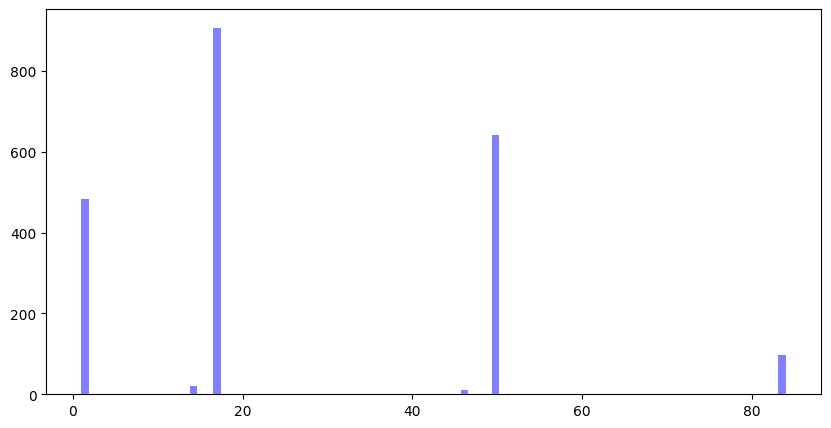

In [238]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(
    class_preds.argmax(axis=1),
    bins=len(class_labels),
    alpha=0.5,
    label="Predicted",
    color="blue",
)

In [229]:
# Look at the prediction of single rows
from IPython.display import clear_output

print(predictions.shape)
i = 0
while i < len(y_test_cat_tensor):
    class_pred = class_preds[i]
    suitedness_pred = suitedness_preds[i][0]
    print(f"Predicted class: {class_labels[np.argmax(class_pred)]}")
    print(f"Predicted prob for predicted class: {class_pred[np.argmax(class_pred)]}")
    true_group_unsuited = np.argmax(y_test_cat_tensor[i])
    print("True class:", class_labels[true_group_unsuited])
    print(f"Prob for true class: {class_pred[true_group_unsuited]}")
    print()
    print(f"Prob suited: {suitedness_pred}")
    print(f"Was suited?: {y_test_suited_tensor[i].numpy()}")
    print()
    print("Predicted probabilities:")
    print(
        pd.DataFrame(
            dict(zip(class_labels, class_pred)), index=["probability"]
        ).T.sort_values("probability", ascending=False)
    )
    if input("Continue? (Y/n)").lower()[:1] == "n":
        break
    i += 1
    clear_output(wait=True)

Predicted class: ('K', '9')
Predicted prob for predicted class: 0.02157946676015854
True class: ('J', '8')
Prob for true class: 0.016903473064303398

Prob suited: 0.25569579005241394
Was suited?: [0.]

Predicted probabilities:
      probability
K  9     0.021579
A  Q     0.019622
10 6     0.019399
A  8     0.017540
K  Q     0.017451
...           ...
4  4     0.004676
5  5     0.003947
Q  Q     0.003713
K  K     0.003527
A  A     0.002990

[91 rows x 1 columns]
